# Pooled fate interactions: count and fraction exposure

Train exactly two mean-curvature models on the five saved organoid folds: pooled interactions with and without the conditional training-reference mean. Both retain learned saturation, signed affine-log-N amplitudes, constant center preferences and shared accommodation. The exposure setting selects fractions or counts; the current run is the count-based reference experiment.

For counts, x_B=(n_B_ring1+0.5*n_B_ring2)/1.5, with no division by neighborhood population. For fractions, replace n by the fraction within each ring. In both cases F_AB(x)=tanh(alpha_AB*x)/tanh(alpha_AB). With counts this normalization specifies F(1)=1 at one weighted-count unit; values above 1 are allowed and approach 1/tanh(alpha). Alpha and amplitudes therefore have different units/conventions across representations. Keeping the same numerical penalty grid is a controlled implementation choice, not invariant regularization under a change of units.

The preferred field is u_i=a_A+sum_B beta_AB(N)*(F_AB(x_B)-mu_AB); uncentered fits set mu to zero. Prediction solves (I+lambda(N)*L)h=u and restores the saved baseline. No learned distance weights or independent hop signs are used. Count vectors implicitly expose total neighborhood size and are deliberately evaluated as a reference; they are not strictly fate-only inputs.

Reuse the saved mean-curvature targets, baselines, preprocessing and exact train/validation folds. No center-only controls, models without accommodation or new FiLM references are trained. Save models, data bundles, membership, settings and convergence histories. The evaluation notebook compares counts with the already trained fraction models; interpretation is left for the subsequent analysis. Previous executed notebooks and outputs are retained in the fraction run. Reference centering is not generally a pure intercept shift because amplitudes depend on N while center preferences do not.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import copy
import gc
import json
import shutil
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython
from IPython.display import display
from src.artifacts.bundle import load_bundle, save_bundle, graph_membership
from src.artifacts.runs import AnalysisRun
from src.artifacts.provenance import workflow_fingerprint
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy, energy_mse
from src.training.progress import TrainingProgress
torch.set_num_threads(4)
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

## Settings
Select the saved cohort and configure the two matched fits before data loading. All data filters, target preprocessing and outer memberships come from the reference run.

In [2]:
# Data and execution
SOURCE_RUN = 'training_results/mean_curvature_energy_training/logN_signed_half_hop_20260929_145842'  # Saved mean-target inputs and comparison models.
RUN_DIR = PROJECT_ROOT/'training_results/pooled_interaction_training/counts_centered_vs_uncentered_20260930_121245'  # Dedicated resumable output directory.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Float64 energy fitting and inference.
RUN_TRAINING = True  # Fit missing checkpoints and show held-out performance.

SETTINGS = dict(
    # Identity and matched model definitions
    tag='counts_centered_vs_uncentered',  # Purpose of this run.
    variants=['pooled_centered', 'pooled_uncentered'],  # Both retain interactions and accommodation.
    interaction='pooled',  # Fixed positive ring weights before activation.
    exposure_kind='counts',  # 'counts' uses absolute identity counts; 'fractions' uses ring composition.
    ring_weights=[1., .5],  # Documented fixed weights; implementation enforces this choice.
    activation='learned',  # Learn a constant-in-N saturation for each supported pair.
    size_dependent=True,  # Affine-log-N amplitudes and softplus-affine accommodation.
    fixed_alpha=3.,  # Shrinkage reference and fallback for unsupported pairs.
    min_pair_organoids=20,  # Minimum training support for learning saturation.

    # Inner selection and regularization
    seed=42,  # Same inner organoid split as the previous energy fits.
    inner_fraction=.2,  # Inner holdout fraction within each outer training fold.
    pair_ridge_grid=[.0001, .001],  # Same candidate interaction penalties as the reference.
    ridge=.0001,  # Center-preference penalty.
    slope_ridge=.001,  # Additional interaction log-N slope penalty.
    lambda_ridge=.0001,  # Accommodation magnitude penalty.
    alpha_ridge=.00001,  # Log-saturation shrinkage penalty.

    # Numerical fitting
    starts=[[.15, 3., 1], [.8, 10., 1]],  # Initial accommodation and saturation; final entry is ignored for pooled models.
    max_iterations=250,  # Maximum iterations per continuous optimizer call.
    tolerance=.00002,  # Convergence threshold, matching the earlier experiment.
    solver_rtol=1e-11,  # Certified CUDA graph-solve tolerance.
    blas_threads=4,  # CPU linear-algebra thread count.
)

## Restore and verify inputs
Copy self-contained input bundles and baseline models, checking the exact training and validation memberships. Record the complete inherited settings and source files. Existing completed models are resumed, never retrained merely to regenerate the figures.

In [3]:
source = AnalysisRun(PROJECT_ROOT/SOURCE_RUN)
membership = json.loads((source.directory/'splits.json').read_text())
cohort = load_bundle(source.directory/'cohort')
marker_names = list(cohort['all_marker_names'])
SETTINGS.update(source_run=str(source.directory), dataset=source.settings['dataset'], target_indices=[1], residualize=True,
                exclusive_markers=True, inherited_settings=source.settings)
if SETTINGS['ring_weights'] != [1., .5]:
    raise ValueError('This implementation uses fixed weights [1, 0.5].')
if RUN_TRAINING:
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    settings_path = RUN_DIR/'settings.json'
    if settings_path.exists() and json.loads(settings_path.read_text()) != SETTINGS:
        raise ValueError('Settings changed: select a new RUN_DIR.')
    settings_path.write_text(json.dumps(SETTINGS, indent=2))
    (RUN_DIR/'splits.json').write_text(json.dumps(membership, indent=2))
    if not (RUN_DIR/'cohort').exists():
        save_bundle(RUN_DIR/'cohort', cohort, splits=membership)
    for split in membership:
        destination = RUN_DIR/f'inputs/fold_{split["fold"]}_mean'
        inputs = load_bundle(source.directory/f'inputs/fold_{split["fold"]}_mean')
        actual = graph_membership(train=inputs['groups']['train'], validation=inputs['groups']['val'])
        if actual != {k: split[k] for k in ['train', 'validation']}:
            raise ValueError('Input fold mismatch')
        if not destination.exists():
            save_bundle(destination, inputs, splits=split)
    for folder in ['history', 'source_snapshot']:
        (RUN_DIR/folder).mkdir(exist_ok=True)
    snapshot_files = ['src/models/curvature_energy.py', 'src/models/coupled_fate.py', 'src/models/energy_ops.py', 'src/training/energy_fit.py',
                      'legacy/energy_models/notebooks/training/pooled_interaction_training.ipynb']
    for filename in snapshot_files:
        destination = RUN_DIR/'source_snapshot'/filename
        if not destination.exists():
            destination.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(PROJECT_ROOT/filename, destination)
    provenance = dict(code_sha256=workflow_fingerprint(PROJECT_ROOT/'legacy/energy_models/notebooks/training/pooled_interaction_training.ipynb'),
                      device=DEVICE, precision='float64', solver_rtol=SETTINGS['solver_rtol'])
    if not (RUN_DIR/'provenance.json').exists():
        (RUN_DIR/'provenance.json').write_text(json.dumps(provenance, indent=2))
catalog = RUN_DIR/'models.json'
records = json.loads(catalog.read_text()) if catalog.exists() else []
known = {r['key'] for r in records}
print('Output:', RUN_DIR, '| device:', DEVICE)
display(pd.DataFrame([dict(fold=s['fold'], train=len(s['train']), validation=len(s['validation'])) for s in membership]))

Output: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/pooled_interaction_training/counts_centered_vs_uncentered_20260930_121245 | device: cuda


,fold,train,validation
0,0,936,234
1,1,936,234
2,2,936,234
3,3,936,234
4,4,936,234


## Fit the two pooled interaction models
For each fold, use the identical inner membership, penalty grid and two initializations for both centering choices. Linear coefficients are profiled exactly; saturation and accommodation are optimized together. There is no hop-sign search in these models.

In [4]:
progress = TrainingProgress(total_models=len(membership)*len(SETTINGS['variants']), show=True)
if RUN_TRAINING:
    for split in membership:
        fold = split['fold']
        inputs = load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
        train_samples = graph_samples(inputs['groups']['train'], 2)
        val_samples = graph_samples(inputs['groups']['val'], 2)
        for variant in SETTINGS['variants']:
            key = f'{variant}_f{fold}_s{SETTINGS["seed"]}'
            with progress.task(model=variant, depth=2, fold=fold, seed=SETTINGS['seed']):
                if key in known:
                    restored = load_bundle(RUN_DIR/next(r['bundle'] for r in records if r['key']==key))
                    if restored['model'].exposure_kind != SETTINGS['exposure_kind'] or restored['model'].interaction != 'pooled' or restored['model'].center_response != (variant=='pooled_centered'):
                        raise ValueError('Existing checkpoint does not match variant')
                    continue
                model_settings = dict(n_markers=len(marker_names), pairs=True, accommodation=True,
                    activation=SETTINGS['activation'], size_dependent=SETTINGS['size_dependent'],
                    interaction='pooled', center_response=(variant=='pooled_centered'), exposure_kind=SETTINGS['exposure_kind'],
                    fixed_alpha=SETTINGS['fixed_alpha'], min_pair_organoids=SETTINGS['min_pair_organoids'])
                penalties = [dict(ridge=SETTINGS['ridge'], pair_ridge=p, slope_ridge=SETTINGS['slope_ridge'],
                    lambda_ridge=SETTINGS['lambda_ridge'], alpha_ridge=SETTINGS['alpha_ridge']) for p in SETTINGS['pair_ridge_grid']]
                def update(message):
                    print(key+': '+message, flush=True)
                    progress.stage(message)
                started = time.monotonic()
                model, metrics, trials = fit_energy(train_samples, model_settings=model_settings, penalties=penalties,
                    seed=SETTINGS['seed'], inner_fraction=SETTINGS['inner_fraction'], starts=SETTINGS['starts'],
                    max_iterations=SETTINGS['max_iterations'], tolerance=SETTINGS['tolerance'],
                    blas_threads=SETTINGS['blas_threads'], device=DEVICE, solver_rtol=SETTINGS['solver_rtol'], callback=update)
                metrics['fit_seconds'] = time.monotonic()-started
                metrics['validation_mse'] = float(energy_mse(model, val_samples, device=DEVICE).mean())
                record = dict(key=key, name=variant, depth=2, fold=fold, seed=SETTINGS['seed'], target_indices=[1],
                    subset='all', signal='intact', family='energy', bundle=f'models/{key}', input_bundle=f'inputs/fold_{fold}_mean')
                save_bundle(RUN_DIR/record['bundle'], dict(model=model, metrics=metrics, record=record), splits=split)
                trials.to_json(RUN_DIR/'history'/f'{key}.json', orient='records', indent=2)
                records.append(record)
                catalog.write_text(json.dumps(records, indent=2))
                known.add(key)
                print(f'Saved {key}; validation MSE={metrics["validation_mse"]:.7f}; seconds={metrics["fit_seconds"]:.1f}', flush=True)
                del model
                gc.collect()
                if DEVICE=='cuda':torch.cuda.empty_cache()
        del inputs, train_samples, val_samples
    expected = {(v,s['fold']) for s in membership for v in SETTINGS['variants']}
    if {(r['name'],r['fold']) for r in records} != expected:
        raise ValueError('Incomplete model catalog')
    (RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records), folds=len(membership)), indent=2))

pooled_centered_f0_s42: Inner penalty 1/2, start 1


pooled_centered_f0_s42: Continuous fit / sign round 1


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:119: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


pooled_centered_f0_s42: Sign round 1: 0 flips


pooled_centered_f0_s42: Inner penalty 1/2, start 2


...

pooled_uncentered_f4_s42: Continuous fit / sign round 1


pooled_uncentered_f4_s42: Sign round 1: 0 flips


pooled_uncentered_f4_s42: Continuous fit / sign round 1


pooled_uncentered_f4_s42: Sign round 1: 0 flips


Saved pooled_uncentered_f4_s42; validation MSE=0.0040759; seconds=106.6


## Held-out validation overview
Display organoid-weighted physical mean-curvature MSE with one-SEM bands. Restore the earlier signed-hop and FiLM scores for reference; they are not retrained. The evaluation notebook performs the paired comparisons and support-aware fold-consistency analysis.

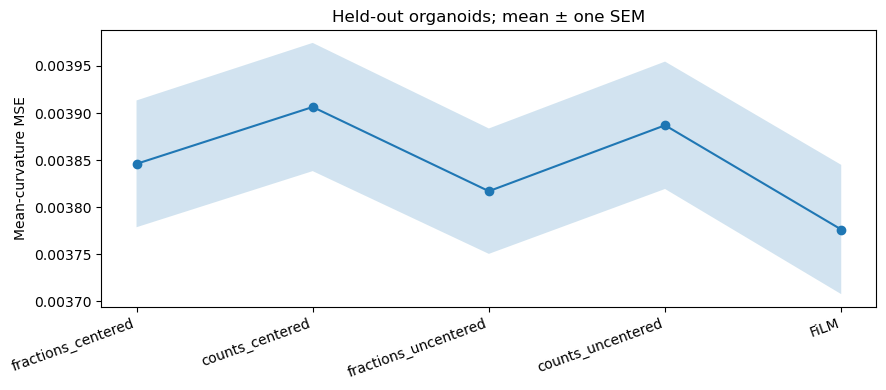

Saved models, baselines, splits, settings and input bundles: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/pooled_interaction_training/counts_centered_vs_uncentered_20260930_121245


In [5]:
rows = []
for split in membership:
    fold = split['fold']
    samples = graph_samples(load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')['groups']['val'], 2)
    for record in [r for r in records if r['fold']==fold]:
        model = load_bundle(RUN_DIR/record['bundle'])['model']
        mse = energy_mse(model, samples, device=DEVICE)
        rows.extend(dict(name=record['name'], fold=fold, organoid_str=s['organoid_str'], N=s['N'], mse=float(v)) for s,v in zip(samples,mse))
scores = pd.DataFrame(rows)
scores.to_csv(RUN_DIR/'validation_mse.csv', index=False)
fraction_run = PROJECT_ROOT/'training_results/pooled_interaction_training/centered_vs_uncentered_20260930_112935'
fraction_scores = pd.read_csv(fraction_run/'validation_mse.csv')
fraction_scores['name'] = fraction_scores.name.replace({'pooled_centered':'fractions_centered','pooled_uncentered':'fractions_uncentered'})
scores['name'] = scores.name.replace({'pooled_centered':'counts_centered','pooled_uncentered':'counts_uncentered'})
previous = pd.read_csv(source.directory/'validation_mse.csv')
previous = previous[previous.name.isin(['learned_accommodated', 'FiLM'])].copy()
previous['name'] = previous.name.replace({'learned_accommodated':'previous_signed_hops'})
combined = pd.concat([scores, fraction_scores, previous], ignore_index=True)
summary = combined.groupby('name').mse.agg(['mean','sem']).reindex(['fractions_centered','counts_centered','fractions_uncentered','counts_uncentered','FiLM'])
fig,ax = plt.subplots(figsize=(9,4))
x = np.arange(len(summary))
ax.plot(x,summary['mean'],'o-')
ax.fill_between(x,summary['mean']-summary['sem'],summary['mean']+summary['sem'],alpha=.2)
ax.set_xticks(x,summary.index,rotation=20,ha='right')
ax.set(ylabel='Mean-curvature MSE',title='Held-out organoids; mean ± one SEM')
fig.tight_layout()
fig.savefig(RUN_DIR/'validation_mse.png',dpi=160)
plt.show()
print('Saved models, baselines, splits, settings and input bundles:',RUN_DIR)